#Bagging
Bagging (Bootstrap Aggregating) is an ensemble learning technique that improves the accuracy and stability of machine learning models. It works by combining multiple models to reduce variance and prevent overfitting.

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier,StackingClassifier,BaggingClassifier,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

bag=BaggingClassifier(estimator=LogisticRegression(),n_estimators=10)
print(bag)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=23)
bag.fit(X_train,y_train)
y_pred=bag.predict(X_test)
print("Accuracy Score of Bagging classifier: ",accuracy_score(y_test,y_pred))

BaggingClassifier(estimator=LogisticRegression())
Accuracy Score of Bagging classifier:  0.905


#Boosting
Boosting is an ensemble learning technique that combines multiple weak models (usually decision trees) to create a stronger predictive model. The key idea is to train models sequentially, with each new model focusing on correcting the errors of the previous ones.

In [2]:
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# Classification example
X_class, y_class = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=23)

# Use AdaBoostClassifier, replacing 'base_estimator' with 'estimator'
ada_class = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50, random_state=42)
ada_class.fit(X_train_class, y_train_class)
y_pred_class = ada_class.predict(X_test_class)
print("Classification Accuracy Score:", accuracy_score(y_test_class, y_pred_class))

# Regression example
X_reg, y_reg = make_regression(n_samples=1000, n_features=20, noise=0.1, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=23)

# Use AdaBoostRegressor
ada_reg = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4), n_estimators=50, random_state=42)
ada_reg.fit(X_train_reg, y_train_reg)
y_pred_reg = ada_reg.predict(X_test_reg)

# Using R² score for regression
print("Regression R² Score:", r2_score(y_test_reg, y_pred_reg))
print("Regression Mean Squared Error:", mean_squared_error(y_test_reg, y_pred_reg))

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Classification Accuracy Score: 0.855
Regression R² Score: 0.7550953583371164
Regression Mean Squared Error: 9035.620940802251


#Gradient Boosting
Gradient Boosting is an ensemble method that combines the predictions of several weak learners (usually decision trees) to produce a stronger model. It works by iteratively adding models to correct errors made by the previous models.

In [ ]:
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# Classification example
X_class, y_class = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=23)

# Use GradientBoostingClassifier with hyperparameters
gb_class = GradientBoostingClassifier(
    n_estimators=100,        # Number of boosting stages to be run
    learning_rate=0.1,       # Step size shrinking to prevent overfitting
    max_depth=3,             # Maximum depth of the individual trees
    random_state=42
)
gb_class.fit(X_train_class, y_train_class)
y_pred_class = gb_class.predict(X_test_class)
print("Classification Accuracy Score:", accuracy_score(y_test_class, y_pred_class))

# Regression example
X_reg, y_reg = make_regression(n_samples=1000, n_features=20, noise=0.1, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=23)

# Use GradientBoostingRegressor with hyperparameters
gb_reg = GradientBoostingRegressor(
    n_estimators=100,        # Number of boosting stages to be run
    learning_rate=0.1,       # Step size shrinking to prevent overfitting
    max_depth=4,             # Maximum depth of the individual trees
    random_state=42
)
gb_reg.fit(X_train_reg, y_train_reg)
y_pred_reg = gb_reg.predict(X_test_reg)

# Using R² score for regression
print("Regression R² Score:", r2_score(y_test_reg, y_pred_reg))
print("Regression Mean Squared Error:", mean_squared_error(y_test_reg, y_pred_reg))

Classification Accuracy Score: 0.89
Regression R² Score: 0.8937493400754741
Regression Mean Squared Error: 3920.059175969481


#XGBoost
XGBoost (Extreme Gradient Boosting) is a powerful machine learning algorithm designed for both classification and regression tasks. It is an optimized implementation of gradient boosting that focuses on performance and efficiency.

XGBoost is an advanced gradient boosting technique that builds and combines decision trees to improve predictive accuracy and computational efficiency. It uses gradient boosting principles but incorporates additional features to enhance performance.

In [ ]:
from xgboost import XGBClassifier
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time
import warnings

# Generate synthetic data
X, y = make_classification(n_samples=10000, class_sep=0.5, random_state=23)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# XGBoost Classifier
start = time.time()
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
xgb_time = time.time() - start
xgb_accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost time: {xgb_time:.4f} seconds")
print(f"XGBoost accuracy: {xgb_accuracy:.4f}")
print("*" * 90)
warnings.filterwarnings("ignore")

# Decision Tree Classifier
start = time.time()
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
dt_time = time.time() - start
dt_accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree time: {dt_time:.4f} seconds")
print(f"Decision Tree accuracy: {dt_accuracy:.4f}")
print("*" * 90)

# AdaBoost Classifier
start = time.time()
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
ada_time = time.time() - start
ada_accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost time: {ada_time:.4f} seconds")
print(f"AdaBoost accuracy: {ada_accuracy:.4f}")
print("*" * 90)

# Gradient Boosting Classifier
start = time.time()
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
gb_time = time.time() - start
gb_accuracy = accuracy_score(y_test, y_pred)
print(f"Gradient Boosting time: {gb_time:.4f} seconds")
print(f"Gradient Boosting accuracy: {gb_accuracy:.4f}")
print("*" * 90)

XGBoost time: 2.0527 seconds
XGBoost accuracy: 0.8555
******************************************************************************************
Decision Tree time: 0.8095 seconds
Decision Tree accuracy: 0.8065
******************************************************************************************
AdaBoost time: 3.5484 seconds
AdaBoost accuracy: 0.8410
******************************************************************************************
Gradient Boosting time: 8.2360 seconds
Gradient Boosting accuracy: 0.8655
******************************************************************************************


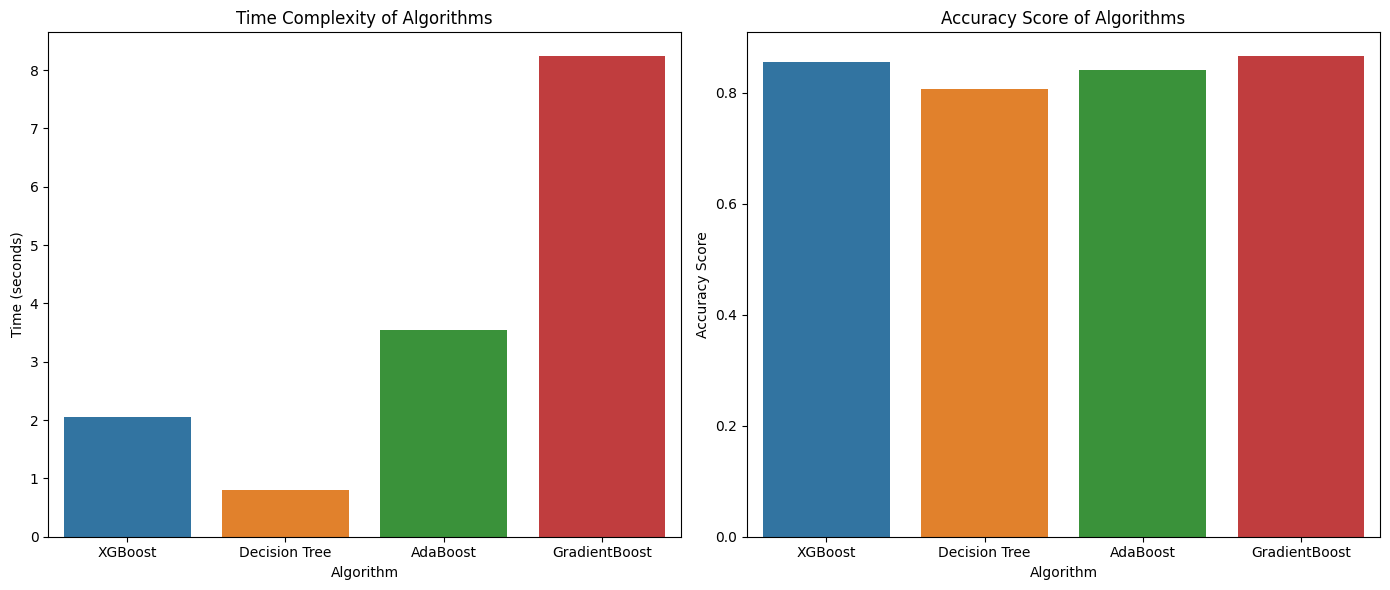

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create DataFrame
Accuracy_time = pd.DataFrame({
    "Algorithm": ["XGBoost", "Decision Tree", "AdaBoost", "GradientBoost"],
    "Time": [xgb_time, dt_time, ada_time, gb_time],
    "Accuracy Score": [xgb_accuracy, dt_accuracy, ada_accuracy, gb_accuracy]
})

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# Plot Time Complexity
sns.barplot(x="Algorithm", y="Time", data=Accuracy_time, ax=axes[0],hue="Algorithm")
axes[0].set_title("Time Complexity of Algorithms")
axes[0].set_xlabel("Algorithm")
axes[0].set_ylabel("Time (seconds)")

# Plot Accuracy Score
sns.barplot(x="Algorithm", y="Accuracy Score", data=Accuracy_time, ax=axes[1],hue="Algorithm")
axes[1].set_title("Accuracy Score of Algorithms")
axes[1].set_xlabel("Algorithm")
axes[1].set_ylabel("Accuracy Score")

# Adjust layout
plt.tight_layout()
plt.show()

#Voting
Voting combines predictions from multiple different models (classifiers or regressors) and makes a final prediction based on the majority vote (for classification) or averaging (for regression).
It uses same data different models.

In [ ]:
# Import necessary libraries for generating synthetic datasets, models, and evaluation metrics
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier, StackingClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

# Generate a synthetic dataset with 1000 samples and a moderate class separation (class_sep=0.7)
X, y = make_classification(n_samples=1000, class_sep=0.7)

# Split the dataset into training and testing sets (default is 75% training, 25% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Define a list of algorithms for the VotingClassifier, using 3 base models: Decision Tree, KNN, and Logistic Regression
algorithms = [("DT", DecisionTreeClassifier()),       # Decision Tree
              ("KnnClassifier", KNeighborsClassifier()),  # K-Nearest Neighbors
              ("Logistic Regression", LogisticRegression())]  # Logistic Regression

# Initialize the VotingClassifier with the chosen algorithms, using hard voting (majority vote)
vc = VotingClassifier(estimators=algorithms, voting="hard")

# Fit the VotingClassifier on the training data
vc.fit(X_train, y_train)

# Make predictions on the test data
y_pred = vc.predict(X_test)

# Print the accuracy score by comparing the predictions with the true labels of the test set
print("Accuracy Score : ", accuracy_score(y_test, y_pred))

Accuracy Score :  0.82


#Stacking
Stacking in machine learning is an ensemble technique where multiple models (called base models) are trained to make predictions, and then a separate model (called a meta-learner) is trained to combine their predictions into a final output. The meta-learner uses the predictions of the base models as its input to make more accurate predictions.
It uses same data but different models.
The Output of Base learner acts as input for the Meta learner to make final predictions.

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

X,y=make_classification(n_samples=2000)
algorithms=[("DT",DecisionTreeClassifier()),
            ("KnnClassifier",KNeighborsClassifier()),
            ("Logistic Regression",LogisticRegression())]
final_algo=DecisionTreeClassifier(random_state=23)
stack=StackingClassifier(estimators=algorithms,final_estimator=final_algo,n_jobs=-1)
print(stack)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=23)
stack.fit(X_train,y_train)
y_pred=stack.predict(X_test)
print("Accuracy Score of Stacking :  ",accuracy_score(y_test,y_pred))

StackingClassifier(estimators=[('DT', DecisionTreeClassifier()),
                               ('KnnClassifier', KNeighborsClassifier()),
                               ('Logistic Regression', LogisticRegression())],
                   final_estimator=DecisionTreeClassifier(random_state=23),
                   n_jobs=-1)
Accuracy Score of Stacking :   0.86
